# Handle subWorkflows

### Setting API Keys

In [1]:
import os
from dotenv import load_dotenv

# Load variables from the .env file into the environment
load_dotenv()
# os.environ['LANGCHAIN_TRACING_V2'] = 'true'
# os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
# os.environ['LANGCHAIN_PROJECT'] = 'Sub-Workflows'
# os.environ['LANGCHAIN_API_KEY'] = os.getenv("LANGCHAIN_API_KEY")
os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")

### Building Basic ChatBot

In [2]:
import os
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import START,END,MessagesState,StateGraph
from operator import add
from typing_extensions import TypedDict
from typing import List, Optional, Annotated

os.environ['GROQ_API_KEY'] = os.getenv("GROQQ_API_KEY")
llm = ChatGroq(model="llama3-8b-8192", temperature=0)


# reply = llm.invoke("hi")
# output_parser = StrOutputParser()
# output_parser.parse(reply.content)

In [3]:
class q1_state(TypedDict):
    question : str
    ans_1 : str

class output_q1_state(TypedDict):
    ans_1 : str


def response_1(state):
    question = state["question"]
    if 'Who' in question:
        return {'ans_1' : 'He is a Graduated in Bs Computer Science'}
    
graph_1 = StateGraph(q1_state,output=output_q1_state)
graph_1.add_node("response_1",response_1)

graph_1.add_edge(START,"response_1")
graph_1.add_edge("response_1",END)

app_1 = graph_1.compile()

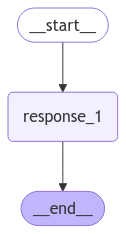

In [4]:
# app_1.invoke({"question" : "Who is Ali"})

from IPython.display import Image, display

try:
    display(Image(app_1.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)
    pass


In [5]:
class q2_state(TypedDict):
    question : str
    ans_2 : str

class output_q2_state(TypedDict):
    ans_2 : str


def response_2(state):
    question = state["question"]
    if 'Who' in question:
        return {'ans_2' : 'Currently he is working as an Ai Engineer'}
    
graph_2 = StateGraph(q2_state,output=output_q2_state)
graph_2.add_node("response_2",response_2)

graph_2.add_edge(START,"response_2")
graph_2.add_edge("response_2",END)

app_2 = graph_2.compile()

In [6]:
# app_2.invoke({"question" : "Who is Ali"})

from IPython.display import Image, display

try:
    display(Image(app_2.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)
    pass


('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))


In [7]:
import operator
from typing import Annotated

class finalState(TypedDict):
    # question : Annotated[str, operator.add]
    question : str
    ans_1 : str
    ans_2: str
    final_ans: str


wokflow=StateGraph(finalState)


def call_model(state):
    context_1 = state["ans_1"]
    context_2 = state["ans_2"]
    question = state["question"]
    msg = f"context :\n {context_1} \n {context_2} \n Main question: {question} \n please provide the answer of question according to given context and donot tell naything extra which you donot know , and make sure to answer like a humen"
    reply = llm.invoke(msg)
    return {"final_ans" : reply.content}



wokflow.add_node("model", call_model)
wokflow.add_node("respose1", app_1)
wokflow.add_node("respose2", app_2)
# wokflow.add_node("respose1", graph_1.compile())
# wokflow.add_node("respose2", graph_2.compile())

wokflow.add_edge(START, "respose1")
wokflow.add_edge(START, "respose2")
wokflow.add_edge(["respose1", "respose2"], "model")
wokflow.add_edge("model", END)

app=wokflow.compile()

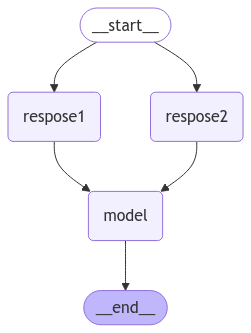

In [8]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

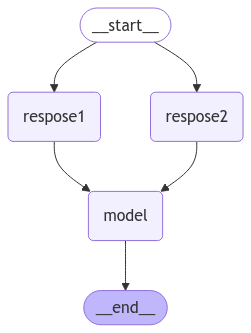

In [9]:
# Setting xray to 1 will show the internal structure of the nested graph
display(Image(app.get_graph(xray=1).draw_mermaid_png()))

In [10]:
app_1.invoke({"question" : "Who is Ali"})

{'ans_1': 'He is a Graduated in Bs Computer Science'}

In [11]:
app_2.invoke({"question" : "Who is Ali"})

{'ans_2': 'Currently he is working as an Ai Engineer'}

In [12]:
app.invoke({"question" : "Who is Ali"})

{'question': 'Who is Ali',
 'ans_1': 'He is a Graduated in Bs Computer Science',
 'ans_2': 'Currently he is working as an Ai Engineer',
 'final_ans': 'Based on the context, I\'d say: "Ali is a guy who has a Bachelor\'s degree in Computer Science and is currently working as an AI Engineer."'}

In [13]:
for event in app.stream({"question" : "Who is Ali"},stream_mode='values'):
    print(event)
    print("_"*30)

{'question': 'Who is Ali'}
______________________________
{'question': 'Who is Ali', 'ans_1': 'He is a Graduated in Bs Computer Science', 'ans_2': 'Currently he is working as an Ai Engineer'}
______________________________
{'question': 'Who is Ali', 'ans_1': 'He is a Graduated in Bs Computer Science', 'ans_2': 'Currently he is working as an Ai Engineer', 'final_ans': 'Based on the context, I\'d say: "Ali is a guy who has a Bachelor\'s degree in Computer Science and is currently working as an AI Engineer."'}
______________________________


In [14]:
for event in app.stream({"question" : "Who is Ali"},stream_mode='updates'):
    print(event)
    print("_"*30)

{'respose1': {'ans_1': 'He is a Graduated in Bs Computer Science'}}
______________________________
{'respose2': {'ans_2': 'Currently he is working as an Ai Engineer'}}
______________________________
{'model': {'final_ans': 'Based on the context, I\'d say: "Ali is a guy who has a Bachelor\'s degree in Computer Science and is currently working as an AI Engineer."'}}
______________________________


In [15]:
app.get_graph().to_json()

{'nodes': [{'id': '__start__', 'type': 'schema', 'data': '__start__'},
  {'id': 'model',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'utils', 'runnable', 'RunnableCallable'],
    'name': 'model'}},
  {'id': 'respose1',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'graph', 'state', 'CompiledStateGraph'],
    'name': 'respose1'}},
  {'id': 'respose2',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'graph', 'state', 'CompiledStateGraph'],
    'name': 'respose2'}},
  {'id': '__end__', 'type': 'schema', 'data': '__end__'}],
 'edges': [{'source': '__start__', 'target': 'respose1'},
  {'source': '__start__', 'target': 'respose2'},
  {'source': 'model', 'target': '__end__'},
  {'source': 'respose1', 'target': 'model'},
  {'source': 'respose2', 'target': 'model'}]}

# Convert Json To Graph

In [16]:
from inspect import isframe
from langchain_core.prompts import ChatPromptTemplate
from typing import Dict, TypedDict, Optional
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from typing import Dict, Callable
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END, START
from typing import Annotated, List, Sequence
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
import json
import os


In [17]:
node_list = []


# graph states

class q1_state(TypedDict):
    question : str
    ans_1 : str

class output_q1_state(TypedDict):
    ans_1 : str

class q2_state(TypedDict):
    question : str
    ans_2 : str

class output_q2_state(TypedDict):
    ans_2 : str

class finalState(TypedDict):
    question : str
    ans_1 : str
    ans_2: str
    final_ans: str


class GraphState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    #Inputs:
    youtube_url: str
    input_text: str
    content: str
    audience: str
    tone: str
    length: str
    website_url: str
    prompt: str
    context: str
    #Outputs:
    transcript: str
    blog: str
    summary : str
    website_scraped_content: str
    ai_response: str



# Helping Functions
def check_previous_node(node_id,node_list):
    target = node_id
    previous_element = ''
    if target in node_list:
        index = node_list.index(target)  # Get the index of the target element
        if index > 0:  # Check if there is a previous element
            previous_element = node_list[index - 1]
            print(f"The previous element of '{target}' is '{previous_element}'.")
        else:
            print(f"'{target}' has no previous element.")
    else:
        print(f"'{target}' is not in the list.")
    return previous_element

# def extract_nodes(input_json):
#   flow = []
#   edges = input_json['edges']
#   current_node = '__start__'
#   while current_node != '__end__':
#       flow.append(current_node)
#       # Find the next node in the flow:
#       next_edge = next(edge for edge in edges if edge['source'] == current_node)
#       current_node = next_edge['target']
#   flow.append('__end__')
#   return flow

# all nodes output registory
# all_node_outputs = {
#     'Ask_AI': 'ai_response',
#     'Website_Scraper':'website_scraped_content',
#     # 'Blog_Writer' : 'blog',
#     'Get_Youtube_Transcript': 'transcript',
#     'summarize': 'summary'
# }

# ________________________________________________


function_registry = {
    "response_1": response_1,
    "response_2": response_2,
}

# function ragistory
def get_function_reference(function_name: str) -> Callable:
    return function_registry.get(function_name, lambda: None)




# _______________________________________________________

#########################################################################################################################################


# graph builder
def group_by_source_and_function(dicts):
    grouped = {}
    for item in dicts:
        key = (item['source'], item['function'])
        if key not in grouped:
            grouped[key] = []
        grouped[key].append(item)
    return grouped



def build_graph_from_json(output_json: Dict,  mainstate = None, inputstate = None, outputstate = None) -> Callable:
    input_var_dict={}
    conditional_edges=[]

    # Step 1: Initialize the graph with config
    workflow = StateGraph(state_schema=mainstate, input=inputstate, output=outputstate)

    # Step 2: Add all nodes to the workflow based on the output JSON
    for node in output_json["nodes"]:
        node_id = node["id"]

        # Skip special start and end nodes in this step
        if node_id in ["__start__", "__end__"]:
            continue

        # Retrieve the function for this node
        function_name = node["data"].get("name")
        function_ref = get_function_reference(function_name)

        # Add the node with the associated function
        workflow.add_node(node_id, function_ref)

        # extract input variables from node-json
        input_var_dict.update(node["inputs"])



    # Step 3: Set the entry point if there's an edge from "__start__"
    for edge in output_json["edges"]:
        if edge["source"] == "__start__":
            workflow.add_edge(edge["source"],edge["target"])
            # workflow.set_entry_point(edge["target"])
            
    # Step 4: Set the end point if there's an edge from "__end__"
    for edge in output_json["edges"]:
      if not "conditional" in edge:
        if edge["target"] == "__end__":
            workflow.add_edge(edge["source"],edge["target"])
            

    # Step 5: Add edges to the workflow
    for edge in output_json["edges"]:
        source = edge["source"]
        target = edge["target"]

        # Skip "__start__" and "__end__" here, as they have special handling
        if source == "__start__" or target == "__end__":
            continue

        # Determine if the edge is conditional
        # conditional = edge.get("conditional", "False") == "True"
        if "conditional" in edge:
            # Retrieve the conditional edges and append to seprate conditional lists
            conditional_edges.append(edge)
        else:
            # Add a normal edge if it's not conditional
            workflow.add_edge(source, target)


    if conditional_edges:
      all_conditional_edges= group_by_source_and_function(conditional_edges)

      for conditional_edge in all_conditional_edges:
        conditional_dict={}
        edge_source, edge_function = conditional_edge
        for edge in all_conditional_edges[conditional_edge]:
          conditional_dict[edge['data']]=edge['target']

        function_ref = get_function_reference(edge_function)
        workflow.add_conditional_edges(edge_source, function_ref, conditional_dict)

      return workflow,input_var_dict


    else:
      return workflow,input_var_dict


def graph_builder(input_json = None , mainstate = None, inputstate = None, outputstate = None):
  workflow,input_dict = build_graph_from_json(output_json = input_json, mainstate = mainstate, inputstate = inputstate, outputstate = outputstate)
  app = workflow.compile()
  # node_list = extract_nodes(input_json)
  # print(f"The Nodes are(In order):\n {node_list}")
  # return app,input_dict,node_list
  return app,input_dict


In [18]:
app.get_graph().to_json()

{'nodes': [{'id': '__start__', 'type': 'schema', 'data': '__start__'},
  {'id': 'model',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'utils', 'runnable', 'RunnableCallable'],
    'name': 'model'}},
  {'id': 'respose1',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'graph', 'state', 'CompiledStateGraph'],
    'name': 'respose1'}},
  {'id': 'respose2',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'graph', 'state', 'CompiledStateGraph'],
    'name': 'respose2'}},
  {'id': '__end__', 'type': 'schema', 'data': '__end__'}],
 'edges': [{'source': '__start__', 'target': 'respose1'},
  {'source': '__start__', 'target': 'respose2'},
  {'source': 'model', 'target': '__end__'},
  {'source': 'respose1', 'target': 'model'},
  {'source': 'respose2', 'target': 'model'}]}

In [19]:
json_app_1 ={
'nodes': 
 [{'id': '__start__', 'type': 'schema', 'data': '__start__'},
 
  {'id': 'response_1',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'utils', 'runnable', 'RunnableCallable'], 'name': 'response_1'},
   'inputs': {'question': "Who is Ali"},
   'output': {'ans_1': ''}},
  
  {'id': '__end__', 'type': 'schema', 'data': '__end__'}],

 'edges': 
 [{'source': '__start__', 'target': 'response_1'},
  {'source': 'response_1', 'target': '__end__'}]}



json_app_2 ={
  'nodes': 
  [{'id': '__start__', 'type': 'schema', 'data': '__start__'},
   
  {'id': 'response_2',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'utils', 'runnable', 'RunnableCallable'],'name': 'response_2'},
   'inputs': {'question': "Who is Ali"},
   'output': {'ans_2': ''}},

  {'id': '__end__', 'type': 'schema', 'data': '__end__'}],
 
 'edges': 
 [{'source': '__start__', 'target': 'response_2'},
  {'source': 'response_2', 'target': '__end__'}]}



json_app ={
  'nodes': 
  [{'id': '__start__', 'type': 'schema', 'data': '__start__'},
   
  {'id': 'model',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'utils', 'runnable', 'RunnableCallable'],'name': 'model'},
   'inputs': {'question': "Who is Ali"},
   'output': {'final_ans': ''}},

  {'id': 'response1',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'graph', 'state', 'CompiledStateGraph'],'name': 'response1'},
   'inputs': {'question': "Who is Ali"},
   'output': {'ans_1': ''}},

  {'id': 'response2',
   'type': 'runnable',
   'data': {'id': ['langgraph', 'graph', 'state', 'CompiledStateGraph'],'name': 'response2'},
   'inputs': {'question': "Who is Ali"},
   'output': {'ans_2': ''}},

  {'id': '__end__', 'type': 'schema', 'data': '__end__'}],

 'edges': 
 [{'source': '__start__', 'target': 'response1'},
  {'source': '__start__', 'target': 'response2'},
  {'source': 'model', 'target': '__end__'},
  {'source': 'response1', 'target': 'model'},
  {'source': 'response2', 'target': 'model'}]}

#### My Plan

- Handle the mutiple graph satates (improve the builder function to accept mutiple graphstate)
- first compile the app1 and app2
- save the app1 and app2 object and save to the function ragistory

In [20]:
from pprint import pprint
pprint(json_app_1, sort_dicts=False)

{'nodes': [{'id': '__start__', 'type': 'schema', 'data': '__start__'},
           {'id': 'response_1',
            'type': 'runnable',
            'data': {'id': ['langgraph',
                            'utils',
                            'runnable',
                            'RunnableCallable'],
                     'name': 'response_1'},
            'inputs': {'question': 'Who is Ali'},
            'output': {'ans_1': ''}},
           {'id': '__end__', 'type': 'schema', 'data': '__end__'}],
 'edges': [{'source': '__start__', 'target': 'response_1'},
           {'source': 'response_1', 'target': '__end__'}]}


In [21]:
compile_app_1,input_dict=graph_builder(input_json=json_app_1, mainstate=q1_state, outputstate=output_q1_state)

In [22]:
compile_app_1.invoke(input_dict)

{'ans_1': 'He is a Graduated in Bs Computer Science'}

In [23]:
compile_app_2,input_dict=graph_builder(input_json=json_app_2, mainstate=q2_state, outputstate=output_q2_state)

In [24]:
compile_app_2.invoke(input_dict)

{'ans_2': 'Currently he is working as an Ai Engineer'}

In [25]:
function_registry = {    
    "response1": compile_app_1,
    "response2": compile_app_2,
    "model": call_model
}

In [26]:
function_registry

{'response1': <langgraph.graph.state.CompiledStateGraph at 0x19c17503f20>,
 'response2': <langgraph.graph.state.CompiledStateGraph at 0x19c1754baa0>,
 'model': <function __main__.call_model(state)>}

In [27]:
compile_main_app,final_input_dict=graph_builder(input_json=json_app, mainstate=finalState)

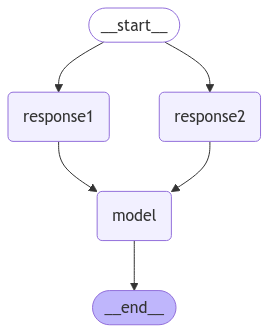

In [28]:

display(Image(compile_main_app.get_graph(xray=1).draw_mermaid_png()))

In [29]:
for event in compile_main_app.stream(final_input_dict,stream_mode="values"):
    print(event)
    print("__________________________")

{'question': 'Who is Ali'}
__________________________
{'question': 'Who is Ali', 'ans_1': 'He is a Graduated in Bs Computer Science', 'ans_2': 'Currently he is working as an Ai Engineer'}
__________________________
{'question': 'Who is Ali', 'ans_1': 'He is a Graduated in Bs Computer Science', 'ans_2': 'Currently he is working as an Ai Engineer', 'final_ans': 'Based on the context, I\'d say: "Ali is a guy who has a Bachelor\'s degree in Computer Science and is currently working as an AI Engineer."'}
__________________________
